# 5.0 Model training - LightGBM - Optuna search


## Imports


In [1]:
import numpy as np
import joblib
import json
import shap
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_log_error

from recruit_restaurant_visitor_forecasting.config import (
    AIR_RESTAURANT_ID_COL,
    MODELS_DIR,
    VISIT_DATE_COL,
    DAY_OF_WEEK_COL,
    VISITORS_NBR_COL,
    CITY_COL,
    RANDOM_SEED,
)
from recruit_restaurant_visitor_forecasting.dataset import read_csv, DataDir, save_csv
from recruit_restaurant_visitor_forecasting.features import GOLDEN_WEEK_FLG
from recruit_restaurant_visitor_forecasting.modeling.train import (
    load_data,
    prepare_features,
    shap_fs,
    lgbm_optuna_search,
    train_test_split_by_date,
)
from recruit_restaurant_visitor_forecasting.plots import plot_daily_pred
from recruit_restaurant_visitor_forecasting.utils import (
    merge_daily_pred,
    get_format,
    optuna_cv_results_to_df,
)
from recruit_restaurant_visitor_forecasting.modeling.predict import recursive_predict

2026-01-23 20:10:32.069 | INFO     | recruit_restaurant_visitor_forecasting.config:<module>:12 - PROJ_ROOT path is: D:\mentoring_program


In [2]:
CV_SPLITS = 5
TEST_SIZE = 0.2
FIRST_ITER_TRIALS = 50
SECOND_ITER_TRIALS = 200
USELESS_FEATURES = [
    *[
        VISITORS_NBR_COL + suffix
        for suffix in ["_mean_7", "_mean_14", "_median_7", "_median_28"]
    ],
    GOLDEN_WEEK_FLG,
]
DROP_COLUMNS = [
    AIR_RESTAURANT_ID_COL,
    VISIT_DATE_COL,
    VISITORS_NBR_COL,
    DAY_OF_WEEK_COL,
    CITY_COL,
    *USELESS_FEATURES,
]

FS_VALID_SIZE = 0.2

MODEL_NAME = "lightgbm_optuna_39"
MODEL_PATH = MODELS_DIR / f"{MODEL_NAME}_model.pkl"

## Load and prepare

In [3]:
features, labels = load_data()
features = prepare_features(features)
labels = labels.loc[features.index].reset_index(drop=True)
features = features.reset_index(drop=True)

In [4]:
X = features
y = labels

X_train, X_test, y_train, y_test = train_test_split_by_date(
    X, y, date_col=VISIT_DATE_COL, test_size=TEST_SIZE
)

train_dates = X_train[VISIT_DATE_COL]
test_dates = X_test[VISIT_DATE_COL]

print(f"Train set dates: {train_dates.min()} to {train_dates.max()}")
print(f"Test set dates: {test_dates.min()} to {test_dates.max()}")

Train set dates: 2016-02-01 00:00:00 to 2017-01-22 00:00:00
Test set dates: 2017-01-23 00:00:00 to 2017-04-22 00:00:00


## Training

In [5]:
def print_best_params(optuna_study):
    print("Best parameters:", optuna_study.best_params)
    print(f"Best score: {optuna_study.best_value:.5f}")

### Iteration 1

In [6]:
study, model = lgbm_optuna_search(
    X_train,
    y_train,
    n_jobs=8,
    drop_features=DROP_COLUMNS,
    n_trials=FIRST_ITER_TRIALS,
    n_splits=CV_SPLITS,
    random_state=RANDOM_SEED,
    window_test_size=39,
)
print_best_params(study)

[I 2026-01-23 13:51:44,836] A new study created in memory with name: no-name-271ef1a4-4ce2-43be-9cc1-56b28d627fc4
[I 2026-01-23 13:54:06,722] Trial 6 finished with value: 1.118047686641707 and parameters: {'max_depth': 3, 'learning_rate': 0.008584963355428998, 'n_estimators': 179, 'subsample': 0.8457040130952569, 'colsample_bytree': 0.925616240116215, 'min_child_samples': 21, 'reg_alpha': 0.12969593917308306, 'reg_lambda': 0.020064674796693754, 'num_leaves': 4}. Best is trial 6 with value: 1.118047686641707.
[I 2026-01-23 13:55:27,811] Trial 3 finished with value: 0.9104026741318526 and parameters: {'max_depth': 4, 'learning_rate': 0.13766230157878584, 'n_estimators': 102, 'subsample': 0.8937498019862335, 'colsample_bytree': 0.5770823965244416, 'min_child_samples': 28, 'reg_alpha': 0.6275834087214722, 'reg_lambda': 0.01793477218768338, 'num_leaves': 14}. Best is trial 3 with value: 0.9104026741318526.
[I 2026-01-23 13:55:44,604] Trial 1 finished with value: 0.9070211783494073 and param

Best parameters: {'max_depth': 5, 'learning_rate': 0.05138931661798599, 'n_estimators': 165, 'subsample': 0.5872465066923778, 'colsample_bytree': 0.6943976014375949, 'min_child_samples': 28, 'reg_alpha': 0.37038702326750733, 'reg_lambda': 0.00028445871625267254, 'num_leaves': 21}
Best score: 0.90549


In [7]:
optuna_cv_results_to_df(study).sort_values(["rank_test_score"]).head()

,params,std_test_score,mean_test_score,split_test_0,split_test_1,split_test_2,split_test_3,split_test_4,rank_test_score
48,"{'max_depth': 5, 'learning_rate': 0.0513893166...",0.125035,0.905494,-0.955098,-0.838152,-0.818490,-0.787398,-1.128332,1
17,"{'max_depth': 5, 'learning_rate': 0.0263590194...",0.123971,0.906497,-0.962556,-0.839626,-0.817578,-0.788508,-1.124218,2
21,"{'max_depth': 4, 'learning_rate': 0.0381049054...",0.121217,0.906776,-0.950290,-0.840786,-0.823417,-0.794359,-1.125027,3
1,"{'max_depth': 5, 'learning_rate': 0.0285879957...",0.124823,0.907021,-0.961932,-0.838440,-0.819861,-0.787870,-1.127002,4
25,"{'max_depth': 5, 'learning_rate': 0.0262647242...",0.123258,0.907219,-0.966728,-0.839717,-0.819055,-0.788761,-1.121835,5


### SHAP feature selection

In [8]:
selected_features, feature_stats = shap_fs(
    X_train,
    y_train,
    model.named_steps["model"],
    drop_features=DROP_COLUMNS,
    test_size=FS_VALID_SIZE,
)

### Iteration 2

In [9]:
study, model_shap = lgbm_optuna_search(
    X_train,
    y_train,
    n_jobs=6,
    drop_features=DROP_COLUMNS,
    n_trials=SECOND_ITER_TRIALS,
    n_splits=CV_SPLITS,
    random_state=RANDOM_SEED,
    features_top=selected_features,
    window_test_size=39,
)
print_best_params(study)

[I 2026-01-23 14:19:18,900] A new study created in memory with name: no-name-42814e91-0052-4d72-bbbf-58bd48913019
[I 2026-01-23 14:20:10,678] Trial 0 finished with value: 1.0319416138405004 and parameters: {'max_depth': 3, 'learning_rate': 0.016302560620077376, 'n_estimators': 127, 'subsample': 0.7605338242054298, 'colsample_bytree': 0.9433952716764828, 'min_child_samples': 18, 'reg_alpha': 0.00902772918208749, 'reg_lambda': 0.01430381307656514, 'num_leaves': 7, 'keep_count': 11}. Best is trial 0 with value: 1.0319416138405004.
[I 2026-01-23 14:20:45,193] Trial 1 finished with value: 1.2935303694675486 and parameters: {'max_depth': 5, 'learning_rate': 0.0029590795722315728, 'n_estimators': 111, 'subsample': 0.523257355179304, 'colsample_bytree': 0.7103741578118747, 'min_child_samples': 24, 'reg_alpha': 0.0001674550852205496, 'reg_lambda': 0.9329983667433048, 'num_leaves': 24, 'keep_count': 17}. Best is trial 0 with value: 1.0319416138405004.
[I 2026-01-23 14:21:22,234] Trial 2 finished

Best parameters: {'max_depth': 4, 'learning_rate': 0.2369678834295011, 'n_estimators': 239, 'subsample': 0.7575764225708639, 'colsample_bytree': 0.7663412446622625, 'min_child_samples': 25, 'reg_alpha': 0.22668860032470234, 'reg_lambda': 4.479436736258806, 'num_leaves': 9, 'keep_count': 24}
Best score: 0.88254


In [12]:
cv_results = optuna_cv_results_to_df(study)
cv_results.sort_values(["rank_test_score"]).head()

,params,std_test_score,mean_test_score,split_test_0,split_test_1,split_test_2,split_test_3,split_test_4,rank_test_score
157,"{'max_depth': 4, 'learning_rate': 0.2369678834...",0.106295,0.882544,-0.933104,-0.828963,-0.809807,-0.773956,-1.066892,1
168,"{'max_depth': 4, 'learning_rate': 0.2135584295...",0.106644,0.882768,-0.935128,-0.827197,-0.811675,-0.772916,-1.066924,2
173,"{'max_depth': 4, 'learning_rate': 0.1934142129...",0.106297,0.882785,-0.940072,-0.827556,-0.811579,-0.771239,-1.063478,3
171,"{'max_depth': 4, 'learning_rate': 0.2013197804...",0.105642,0.882802,-0.935999,-0.829954,-0.810973,-0.772829,-1.064254,4
186,"{'max_depth': 4, 'learning_rate': 0.1452983846...",0.108798,0.883075,-0.933288,-0.828021,-0.808858,-0.772607,-1.072604,5


### Scores

In [15]:
y_train_pred = model_shap.predict(X_train)
y_train_pred = np.maximum(y_train_pred, 0)

train_rmsle = np.sqrt(mean_squared_log_error(y_train, y_train_pred))
train_mae = mean_absolute_error(y_train, y_train_pred)
train_r2 = r2_score(y_train, y_train_pred)

print(f"Train set metrics:")
print(f"RMSLE: {train_rmsle:.4f}")
print(f"MAE:  {train_mae:.4f}")

Train set metrics:
RMSLE: 0.8407
MAE:  6.6753


In [16]:
y_test_pred, temp_features = recursive_predict(
    model_shap,
    X_test,
    X_train,
    y_train,
    drop_cols=DROP_COLUMNS,
)

Predicting recursively: 100%|██████████| 90/90 [01:16<00:00,  1.17it/s]


In [17]:
test_rmsle = np.sqrt(mean_squared_log_error(y_test, y_test_pred))
test_mae = mean_absolute_error(y_test, y_test_pred)
test_r2 = r2_score(y_test, y_test_pred)
print(f"\nTest set metrics:")
print(f"RMSLE: {test_rmsle:.4f}")
print(f"MAE:  {test_mae:.4f}")


Test set metrics:
RMSLE: 0.7646
MAE:  6.4063


## Graphs

## SHAP explanation

In [49]:
X_test_clean = model_shap.named_steps["feature_dropper"].transform(X_test)
lgbm = model_shap.named_steps["model"]

explainer = shap.TreeExplainer(lgbm)
shap_values = explainer(X_test_clean)

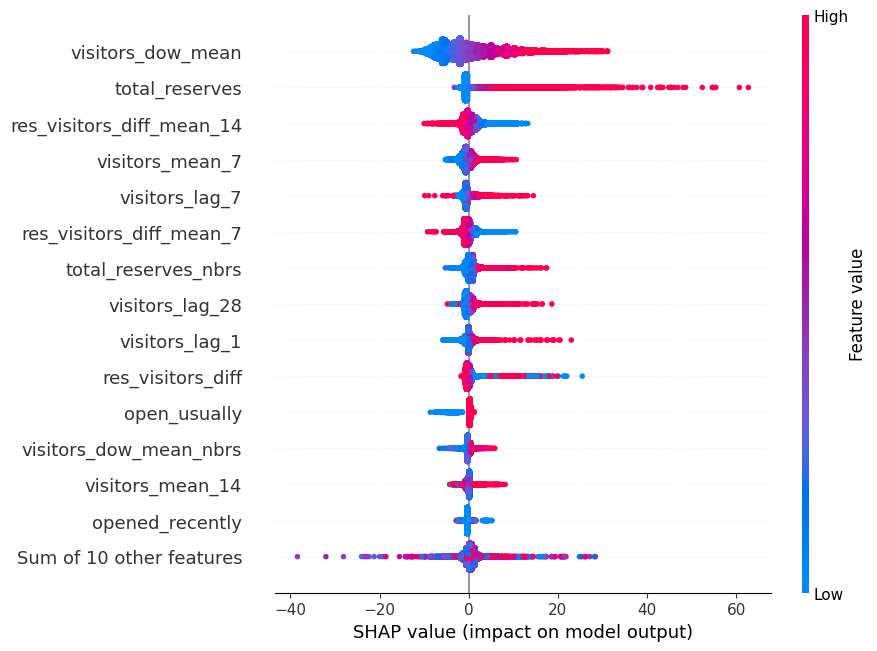

In [50]:
shap.plots.beeswarm(shap_values, max_display=15)

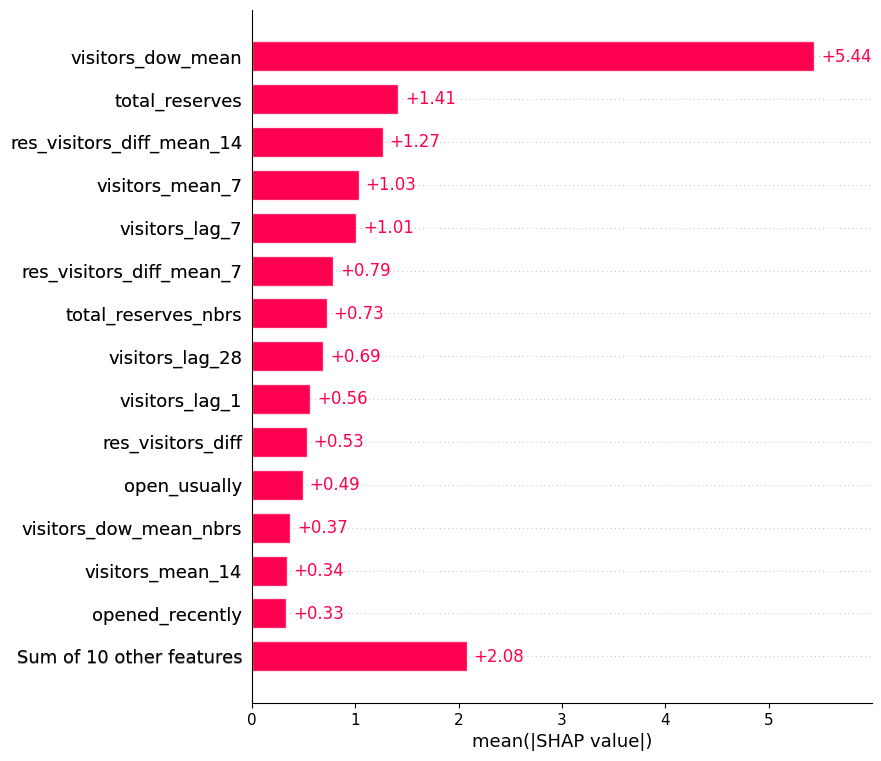

In [51]:
shap.plots.bar(shap_values, max_display=15)

### Visitors per day: actual vs predicted

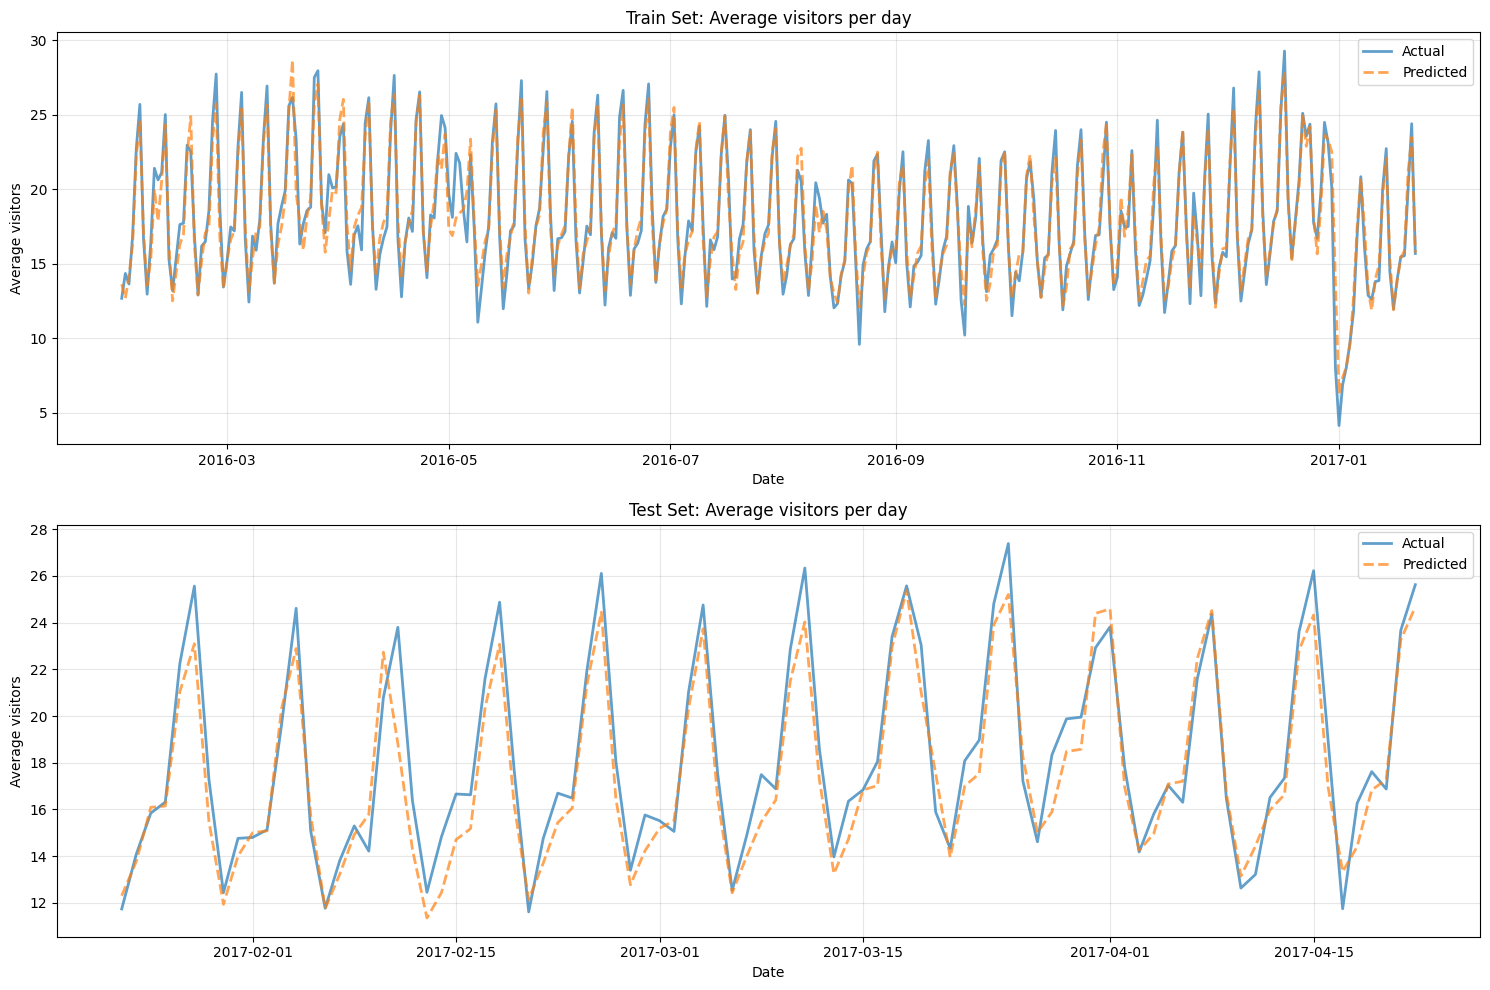

In [18]:
train_daily = merge_daily_pred(train_dates, y_train, y_train_pred)
test_daily = merge_daily_pred(test_dates, y_test, y_test_pred)

fig, axes = plt.subplots(2, 1, figsize=(15, 10))

plot_daily_pred(train_daily, axes[0], train=True)
plot_daily_pred(test_daily, axes[1], train=False)

plt.tight_layout()
plt.show()

## Testing on future data

In [5]:
model_shap = joblib.load(MODEL_PATH)

In [6]:
test_features = read_csv("test_features.csv", DataDir.PROCESSED)
test_features = prepare_features(test_features)
test_features = test_features.reset_index(drop=True)

In [7]:
test_labels, temp_features = recursive_predict(
    model_shap,
    test_features,
    X,
    y,
    drop_cols=DROP_COLUMNS,
)

Predicting recursively: 100%|██████████| 39/39 [03:09<00:00,  4.87s/it]


In [9]:
labels_format = get_format(test_features, test_labels)
save_csv(labels_format, "test_labels.csv", DataDir.PROCESSED)

## Saving model

In [14]:
joblib.dump(model_shap, MODEL_PATH)
params_to_save = {
    "cv_splits": CV_SPLITS,
    "test_size": TEST_SIZE,
    "feature_selection_validation_size": FS_VALID_SIZE,
    "first_iteration_n_trials": FIRST_ITER_TRIALS,
    "second_iteration_n_trials": SECOND_ITER_TRIALS,
    "test_score": test_rmsle,
    "cv result": cv_results.sort_values(["rank_test_score"]).iloc[0].to_dict(),
}

PARAMS_PATH = MODELS_DIR / f"{MODEL_NAME}_params.json"
with open(PARAMS_PATH, 'w', encoding='utf-8') as f:
    json.dump(params_to_save, f, indent=2, ensure_ascii=False)